# Federated Image Classification with ResNet-18

In [ ]:
!pip install torch torchvision -q

## Importing Required Libraries

This section imports the libraries required for building the Federated Learning pipeline.

The notebook mainly uses:

- PyTorch for deep learning
- Torchvision for datasets and transforms
- NumPy for numerical operations
- Matplotlib for plotting results

These libraries together help in model training, client simulation, and evaluation.

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18

from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import gc

## Configuring the Training Device

This cell checks whether CUDA is available.

If a GPU is detected, training is performed on the GPU; otherwise, the CPU is used.

Using a GPU significantly speeds up deep learning training, especially for convolutional neural networks like ResNet-18.

In [ ]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using Device: cuda
GPU: Tesla T4


## Defining Federated Learning Hyperparameters

This section defines the main training settings used throughout the experiment.

Some important parameters include:

- Number of clients
- Clients selected per round
- Number of communication rounds
- Local epochs
- Batch size
- Learning rate

These values directly affect convergence speed, communication cost, and overall model performance.

In [ ]:
NUM_CLIENTS = 20

CLIENTS_PER_ROUND = 4

ROUNDS = 15

LOCAL_EPOCHS = 1

BATCH_SIZE = 16

LEARNING_RATE = 0.0003

## Applying Image Transformations

Before training, the images are preprocessed using augmentation and normalization techniques.

The training data uses:

- Random cropping
- Horizontal flipping
- Normalization

These transformations help improve generalization and reduce overfitting.

---

## Normalization

Pixel values are normalized using:   $x' = \frac{x - \mu}{\sigma}$


where:

- $\mu$ is the dataset mean
- $\sigma$ is the standard deviation

In [ ]:
transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Loading the CIFAR-100 Dataset

## What this code does
This cell downloads and loads:
- Training dataset
- Testing dataset

using the CIFAR-100 dataset from Torchvision.

## About CIFAR-100
CIFAR-100 contains:
- 60,000 color images
- 100 different classes
- 32×32 image size

## Dataset Split
- 50,000 training images
- 10,000 testing images

## Why this dataset is used
CIFAR-100 is commonly used for:
- Image classification research
- Federated Learning experiments
- Deep learning benchmarking

Its large number of classes makes the learning task more challenging.

In [ ]:
train_dataset = datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

print("Training Samples:", len(train_dataset))

print("Testing Samples:", len(test_dataset))

100%|██████████| 169M/169M [00:03<00:00, 43.4MB/s]


Training Samples: 50000
Testing Samples: 10000


## Creating Non-IID Client Datasets

In Federated Learning, client datasets are usually not identically distributed.

This section creates a Non-IID partition of CIFAR-100 across multiple clients.


### IID vs Non-IID Distribution

IID distribution assumes:  $P_k(x,y) = P(x,y)$


Non-IID distribution means: $P_k(x,y) \neq P_j(x,y)$

This means different clients may contain different class distributions.

For example:

- One client may mostly contain animal images
- Another may mostly contain vehicle images

This setup better reflects real-world decentralized data.

In [ ]:
def create_noniid_clients(
    dataset,
    num_clients,
    classes_per_client=10
):

    labels = np.array(dataset.targets)

    client_indices = []

    for client_id in range(num_clients):

        chosen_classes = np.random.choice(
            100,
            classes_per_client,
            replace=False
        )

        indices = []

        for cls in chosen_classes:

            cls_indices = np.where(
                labels == cls
            )[0]

            sampled_indices = np.random.choice(
                cls_indices,
                size=min(50, len(cls_indices)),
                replace=False
            )

            indices.extend(sampled_indices)

        np.random.shuffle(indices)

        client_indices.append(indices)

        print(
            f"Client {client_id}: "
            f"{chosen_classes}"
        )

    client_datasets = [

        Subset(dataset, indices)

        for indices in client_indices
    ]

    return client_datasets

# Generating Federated Clients

## What this code does
This cell creates all client datasets using the previously defined Non-IID partitioning function.

## Output
- 20 simulated clients are created
- Each client contains a different subset of CIFAR-100 classes

## Why this is important
Federated Learning requires:
- Multiple decentralized clients
- Independent local datasets

This step simulates distributed user data.

In [ ]:
client_datasets = create_noniid_clients(
    train_dataset,
    NUM_CLIENTS
)

print("\nCreated Non-IID Clients")

Client 0: [22 79 42  6 91 15 82  9 58 96]
Client 1: [32 53 59 81 30 47  4 42 18 83]
Client 2: [25 54  3 92 62 86 21 27  5 84]
Client 3: [61  2 58  0 75 94 92 80 60 41]
Client 4: [45 30 24 26 34 44 20 42 32 83]
Client 5: [67 60 87 36 56 92 70 76 16 13]
Client 6: [52 44 65 63 92 12  5 88 20 72]
Client 7: [95 35 50 28 81  6 49 31 79 66]
Client 8: [37 23 12 43  3 92 36 61 97 96]
Client 9: [ 8 91 89 42 87 16 71  3 18 22]
Client 10: [61 58  5 81 60 72 53 17 52 22]
Client 11: [96 43 86 75 79 62 22 17 83 16]
Client 12: [49 98 54 82 17 85 65 20 29 26]
Client 13: [60 10 16 21 30 64 52  0 62 43]
Client 14: [55 83 77 76 40 38 18 69 34 74]
Client 15: [40 61 90 21 45 26 75 33 94 73]
Client 16: [ 5 97 96 10 75 57 41 22 35 91]
Client 17: [53 13  6 45 93 75 49 52 91 14]
Client 18: [17 14  3 75 40 51 92 27 98  7]
Client 19: [40 41  8 30 59 44 38 32 63 46]

Created Non-IID Clients


# Initializing the Global ResNet-18 Model

This section initializes the global model used for Federated Learning.

The architecture used is ResNet-18, which introduces residual connections to improve deep network training.

---

## Residual Learning

Instead of learning a direct mapping, ResNet learns: $H(x) = F(x) + x$

where:

- $F(x)$ is the residual mapping
- $x$ is the shortcut connection

These skip connections help reduce the vanishing gradient problem in deep neural networks.

In [ ]:
global_model = resnet18(
    num_classes=100
).to(DEVICE)

print("Global Model Initialized")

Global Model Initialized


## Local Client Training

This function performs local training on a client's private dataset.

Each client independently updates the model parameters using gradient descent.



## Local Weight Update

The model parameters are updated as:


$\theta_{t+1} =
\theta_t - \eta \nabla \mathcal{L}(\theta_t)$

where:

- $\eta$ is the learning rate
- $\mathcal{L}$ is the loss function
- $\nabla \mathcal{L}$ represents the gradient

Only the updated model weights are sent back to the server.

In [ ]:
def train_client(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=1,
        gamma=0.9
    )

    model.train()

    total_loss = 0

    for epoch in range(LOCAL_EPOCHS):

        epoch_loss = 0

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()

        avg_epoch_loss = (
            epoch_loss / len(loader)
        )

        total_loss += avg_epoch_loss

    avg_client_loss = (
        total_loss / LOCAL_EPOCHS
    )

    return model.state_dict(), avg_client_loss

## Federated Averaging (FedAvg)

After local training, the server aggregates the client models into a new global model.

This aggregation is performed using the Federated Averaging algorithm.

---

## FedAvg Equation

The updated global model is computed as:

$w^{(t+1)} =
\sum_{k=1}^{K}
\frac{n_k}{n}
w_k^{(t)}$

where:

- $w_k^{(t)}$ represents the weights from client $k$
- $n_k$ is the number of samples in client $k$
- $n$ is the total number of samples across all selected clients

This allows collaborative learning without sharing raw user data.

In [ ]:
def federated_average(client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], dim=0).mean(dim=0)

    global_model.load_state_dict(global_dict)

    return global_model

## Evaluating the Global Model

This section evaluates the updated global model on the test dataset.

The performance is measured using classification accuracy.


## Accuracy Formula

$\text{Accuracy} =
\frac{\text{Correct Predictions}}
{\text{Total Samples}}
\times 100$

Higher accuracy indicates better generalization performance.

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

# Federated Learning Training Process

This is the main communication loop of the Federated Learning system.

Each communication round consists of:

1. Selecting clients
2. Local client training
3. Server aggregation
4. Global evaluation

---

## Global Aggregation

The server updates the global model using:

$w^{(t+1)} =
\sum_{k \in S_t}
\frac{n_k}{n}
w_k^{(t+1)}$

\
The updated global weights are then broadcast back to clients for the next round.

In [ ]:
round_accuracies = []
round_losses = []

best_accuracy = 0

best_model_weights = None

for round_num in range(ROUNDS):

    start_time = time.time()

    print("=" * 70)
    print(f"ROUND {round_num+1}/{ROUNDS}")
    print("=" * 70)

    selected_clients = np.random.choice(
        NUM_CLIENTS,
        CLIENTS_PER_ROUND,
        replace=False
    )

    print("Selected Clients:", selected_clients)

    client_weights = []
    client_losses = []

    for client_id in selected_clients:

        print(f"\nTraining Client {client_id}...")

        local_model = resnet18(
            num_classes=100
        ).to(DEVICE)

        local_model.load_state_dict(
            global_model.state_dict()
        )

        weights, loss = train_client(
            local_model,
            client_datasets[client_id]
        )

        client_weights.append(weights)
        client_losses.append(loss)

        print(
            f"Client {client_id} "
            f"Loss: {loss:.4f}"
        )

        del local_model

        torch.cuda.empty_cache()

        gc.collect()

    federated_average(client_weights)

    avg_loss = (
        sum(client_losses)
        / len(client_losses)
    )

    accuracy = evaluate_model(global_model)

    round_accuracies.append(accuracy)

    round_losses.append(avg_loss)

    if round_num == 0:
        accuracy_change = accuracy
    else:
        accuracy_change = (
            accuracy
            - round_accuracies[-2]
        )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model_weights = copy.deepcopy(
            global_model.state_dict()
        )

    round_time = (
        time.time() - start_time
    )

    print("\n" + "=" * 70)
    print("ROUND SUMMARY")
    print("=" * 70)

    print(
        f"Average Client Loss : "
        f"{avg_loss:.4f}"
    )

    print(
        f"Global Accuracy     : "
        f"{accuracy:.2f}%"
    )

    print(
        f"Accuracy Change     : "
        f"{accuracy_change:+.2f}%"
    )

    print(
        f"Best Accuracy       : "
        f"{best_accuracy:.2f}%"
    )

    print(
        f"Round Duration      : "
        f"{round_time:.2f} sec"
    )

    print("=" * 70)
    print()

ROUND 1/15
Selected Clients: [10  1  3  2]

Training Client 10...
Client 10 Loss: 2.8132

Training Client 1...
Client 1 Loss: 2.6314

Training Client 3...
Client 3 Loss: 2.7396

Training Client 2...
Client 2 Loss: 3.0143

ROUND SUMMARY
Average Client Loss : 2.7996
Global Accuracy     : 1.80%
Accuracy Change     : +1.80%
Best Accuracy       : 1.80%
Round Duration      : 8.36 sec

ROUND 2/15
Selected Clients: [17 13  1 16]

Training Client 17...
Client 17 Loss: 2.7805

Training Client 13...
Client 13 Loss: 2.5670

Training Client 1...
Client 1 Loss: 2.2786

Training Client 16...
Client 16 Loss: 3.0349

ROUND SUMMARY
Average Client Loss : 2.6652
Global Accuracy     : 4.57%
Accuracy Change     : +2.77%
Best Accuracy       : 4.57%
Round Duration      : 8.81 sec

ROUND 3/15
Selected Clients: [ 5 18  0 11]

Training Client 5...
Client 5 Loss: 2.8907

Training Client 18...
Client 18 Loss: 3.1934

Training Client 0...
Client 0 Loss: 3.1390

Training Client 11...
Client 11 Loss: 2.6467

ROUND SU

# Restoring the Best Global Model

## What this code does
This cell reloads the best-performing model obtained during training.

## Why this is important
During training:
- Accuracy may fluctuate
- Later rounds may reduce performance

Restoring the best model ensures:
- Highest achieved accuracy is preserved
- Final evaluation uses the optimal model

In [ ]:
global_model.load_state_dict(
    best_model_weights
)

print("Best Model Restored")

print(
    f"Best Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model Restored
Best Accuracy: 5.11%


## Visualizing Global Accuracy

This graph shows how the global model accuracy changes across communication rounds.

An increasing accuracy trend generally indicates improved global learning and better collaboration between clients.

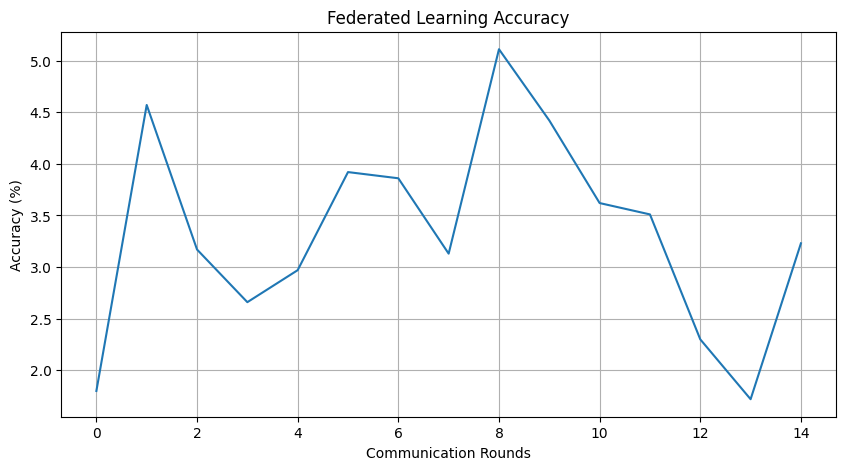

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(round_accuracies)

plt.xlabel("Communication Rounds")

plt.ylabel("Accuracy (%)")

plt.title(
    "Federated Learning Accuracy"
)

plt.grid(True)

plt.show()

## Visualizing Training Loss

This plot tracks the average client training loss during Federated Learning.

Lower loss values generally indicate better convergence during training.

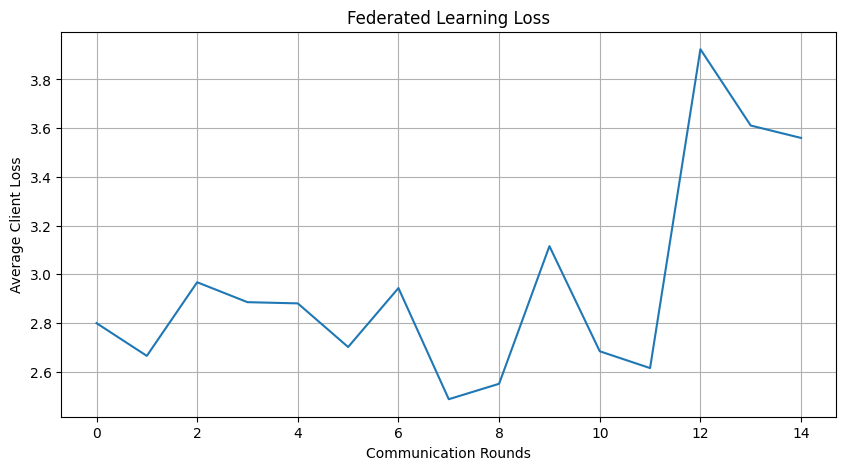

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(round_losses)

plt.xlabel("Communication Rounds")

plt.ylabel("Average Client Loss")

plt.title(
    "Federated Learning Loss"
)

plt.grid(True)

plt.show()

# Conclusion

## Overall Observation
The Federated Learning model showed fluctuating performance across the 15 communication rounds. Although the model was able to learn some meaningful patterns from distributed client data, the overall accuracy remained relatively low due to the challenging experimental setup.

---

# Accuracy Analysis

## Best Accuracy Achieved
The highest global accuracy achieved during training was:

- **5.11%** at **Round 9**

This indicates that the model was able to improve through collaborative learning across clients.

## Accuracy Trend
The accuracy graph shows:
- Initial improvement during early communication rounds
- Several fluctuations throughout training
- A performance drop in later rounds

This unstable behavior suggests that the global model struggled to generalize consistently across all client datasets.

## Reason for Fluctuations
The fluctuations mainly occurred because:
- Clients contained **Non-IID data distributions**
- Different clients had very different class samples
- Only a subset of clients participated each round

As a result:
- Client updates varied significantly
- Federated averaging became unstable
- Global convergence became difficult

---

# Loss Analysis

## Loss Behavior
The average client loss initially remained between:
- **2.5 to 3.0**

However, during later rounds:
- Loss increased sharply
- Some clients produced very high losses

For example:
- Client 14 loss reached **5.3149**
- Client 9 loss reached **4.7247**

This caused instability in the aggregated global model.

## Interpretation
An increase in loss generally indicates:
- Poor generalization
- Conflicting client updates
- Difficulty learning from highly heterogeneous data

---

# Impact of Non-IID Data

## Why Non-IID Data Matters
In this experiment:
- Each client received data from only a subset of classes
- Clients therefore learned different feature distributions

This simulates real-world Federated Learning scenarios where:
- User data is naturally heterogeneous
- Devices do not share identical data distributions

## Challenges Created
Non-IID data caused:
- Slower convergence
- Reduced global accuracy
- High variance in client updates

This is one of the main difficulties in Federated Learning research.

---

# Training Stability

## Positive Outcomes
The experiment successfully demonstrated:
- Federated client training
- Local model updates
- Federated averaging (FedAvg)
- Distributed learning without sharing raw data

## Limitations
The model performance remained limited because:
- Only 4 clients participated per round
- Training was performed for only 15 rounds
- Local epochs were low
- CIFAR-100 is a difficult dataset with 100 classes

---

# Final Conclusion

This experiment successfully implemented a complete Federated Learning pipeline using:
- ResNet-18
- CIFAR-100 dataset
- Non-IID client distributions
- FedAvg aggregation

The results demonstrate that Federated Learning can train a global model collaboratively without centralized data sharing. However, the experiment also highlights the major challenge of Federated Learning:

> Non-IID client data significantly affects convergence and model performance.

Further improvements could be achieved by:
- Increasing communication rounds
- Selecting more clients per round
- Using better aggregation techniques
- Training for more local epochs
- Applying learning rate tuning and regularization

Overall, the project successfully demonstrates the practical workflow and challenges of Federated Learning systems.